# Inicio de proyecto 2

# Carga y limpieza de datos

In [2]:
import pandas as pd

df = pd.read_csv(
    "data/stainless.csv",
    encoding="latin1"
)

df.head()

,SAE Grade,Conditions,UTS (MPa),UTS (Ksi),YS (MPa),YS (ksi),Elongation (%),Reduction (%),Hardness (HB),C (Min),...,Si (Max),Ni (Min),Ni (Max),Cr (Min),Cr (Max),Mo (Min),Mo (Max),Ti (Min),Ti (Max),N
0,Ferritic stainless steels(b),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,405,Annealed bar,483.0,70.0,276.0,40.0,30.0,60,150.0,NaN,...,1.0,NaN,NaN,NaN,13.00,NaN,NaN,NaN,NaN,NaN
2,405,Cold drawn bar,586.0,85.0,483.0,70.0,20.0,60,185.0,NaN,...,1.0,NaN,NaN,NaN,13.00,NaN,NaN,NaN,NaN,NaN
3,409,Annealed bar,450.0,65.0,240.0,35.0,25.0,-,135.0,NaN,...,1.0,NaN,NaN,NaN,11.13,NaN,NaN,NaN,0.75,NaN
4,430,Annealed bar,517.0,75.0,310.0,45.0,30.0,65,155.0,NaN,...,1.0,NaN,NaN,14.0,18.00,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 28 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SAE Grade       62 non-null     object 
 1   Conditions      59 non-null     object 
 2   UTS (MPa)       59 non-null     float64
 3   UTS (Ksi)       59 non-null     float64
 4   YS (MPa)        59 non-null     float64
 5   YS (ksi)        59 non-null     float64
 6   Elongation (%)  59 non-null     float64
 7   Reduction (%)   39 non-null     object 
 8   Hardness (HB)   49 non-null     float64
 9   C (Min)         3 non-null      float64
 10  C (Max)         59 non-null     float64
 11  Mn (Min)        7 non-null      float64
 12  Mn (Max)        59 non-null     float64
 13  P (Min)         0 non-null      float64
 14  P (Max)         59 non-null     float64
 15  S (Min)         0 non-null      float64
 16  S(Max)          59 non-null     object 
 17  Si (Min)        3 non-null      float

SAE Grade          3
Conditions         6
UTS (MPa)          6
UTS (Ksi)          6
YS (MPa)           6
YS (ksi)           6
Elongation (%)     6
Reduction (%)     26
Hardness (HB)     16
C (Min)           62
C (Max)            6
Mn (Min)          58
Mn (Max)           6
P (Min)           65
P (Max)            6
S (Min)           65
S(Max)             6
Si (Min)          62
Si (Max)           6
Ni (Min)          26
Ni (Max)          16
Cr (Min)          18
Cr (Max)           6
Mo (Min)          57
Mo (Max)          55
Ti (Min)          62
Ti (Max)          61
N                 58
dtype: int64

In [4]:
# Seleccionar columnas importantes

columnas = [
    "Conditions",
    "UTS (MPa)",
    "YS (MPa)",
    "Elongation (%)",
    "Hardness (HB)",
    "C (Max)",
    "Cr (Max)",
    "Ni (Max)",
    "Mn (Max)"
]

df = df[columnas]

In [5]:
df.isnull().sum()

Conditions         6
UTS (MPa)          6
YS (MPa)           6
Elongation (%)     6
Hardness (HB)     16
C (Max)            6
Cr (Max)           6
Ni (Max)          16
Mn (Max)           6
dtype: int64

In [6]:
def clasificar_tratamiento(cond):

    cond = str(cond).lower()

    if "annealed" in cond:
        return "Annealed"

    elif "solution" in cond:
        return "Solution Treated"

    elif "cold" in cond:
        return "Cold Worked"

    elif "hot" in cond:
        return "Hot Rolled"

    elif "quenched" in cond:
        return "Quenched"

    else:
        return "Other"


df["Condition_simple"] = df["Conditions"].apply(
    clasificar_tratamiento
)

df[["Conditions", "Condition_simple"]].head(15)

,Conditions,Condition_simple
0,NaN,Other
1,Annealed bar,Annealed
2,Cold drawn bar,Cold Worked
3,Annealed bar,Annealed
4,Annealed bar,Annealed
5,Annealed bar,Annealed
6,Annealed at 815 °C (1500 °F) and cold worked,Annealed
7,Annealed bar,Annealed
8,Annealed at 815 °C (1500 °F) and cold drawn,Annealed
9,NaN,Other


In [7]:
df["Condition_simple"].value_counts()

Condition_simple
Annealed       41
Other          15
Quenched        5
Cold Worked     4
Name: count, dtype: int64

In [8]:
df["Hardness (HB)"] = (
    df["Hardness (HB)"]
    .astype(str)
    .str.extract(r'(\d+)')[0]
)

df["Hardness (HB)"] = pd.to_numeric(
    df["Hardness (HB)"],
    errors="coerce"
)

In [9]:
columnas_numericas = [
    "UTS (MPa)",
    "YS (MPa)",
    "Elongation (%)",
    "Hardness (HB)",
    "C (Max)",
    "Cr (Max)",
    "Ni (Max)",
    "Mn (Max)"
]

for col in columnas_numericas:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

In [10]:
df = df.dropna(subset=[
    "UTS (MPa)",
    "YS (MPa)",
    "Elongation (%)",
    "Hardness (HB)",
    "Cr (Max)",
    "Ni (Max)",
    "Condition_simple"
])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40 entries, 5 to 61
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Conditions        40 non-null     object 
 1   UTS (MPa)         40 non-null     float64
 2   YS (MPa)          40 non-null     float64
 3   Elongation (%)    40 non-null     float64
 4   Hardness (HB)     40 non-null     float64
 5   C (Max)           40 non-null     float64
 6   Cr (Max)          40 non-null     float64
 7   Ni (Max)          40 non-null     float64
 8   Mn (Max)          40 non-null     float64
 9   Condition_simple  40 non-null     object 
dtypes: float64(8), object(2)
memory usage: 3.4+ KB


In [12]:
df.isnull().sum()

Conditions          0
UTS (MPa)           0
YS (MPa)            0
Elongation (%)      0
Hardness (HB)       0
C (Max)             0
Cr (Max)            0
Ni (Max)            0
Mn (Max)            0
Condition_simple    0
dtype: int64

# Gráficas

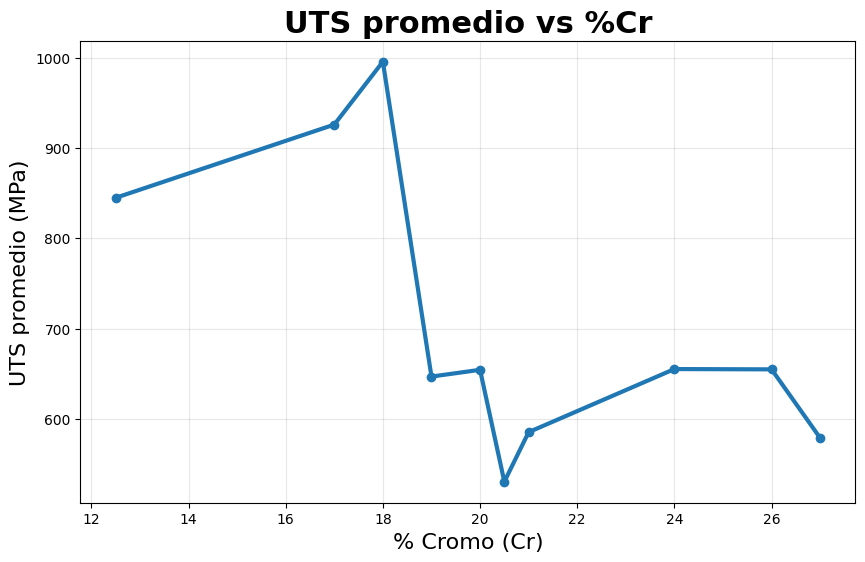

In [13]:
import matplotlib.pyplot as plt

# Promedio por porcentaje de Cr
grafica_cr = df.groupby(
    "Cr (Max)"
)["UTS (MPa)"].mean()

# Gráfica
plt.figure(figsize=(10,6))

plt.plot(
    grafica_cr.index,
    grafica_cr.values,
    marker="o",
    linewidth=3
)

plt.title(
    "UTS promedio vs %Cr",
    fontsize=22,
    fontweight="bold"
)

plt.xlabel(
    "% Cromo (Cr)",
    fontsize=16
)

plt.ylabel(
    "UTS promedio (MPa)",
    fontsize=16
)

plt.grid(True, alpha=0.3)

plt.show()

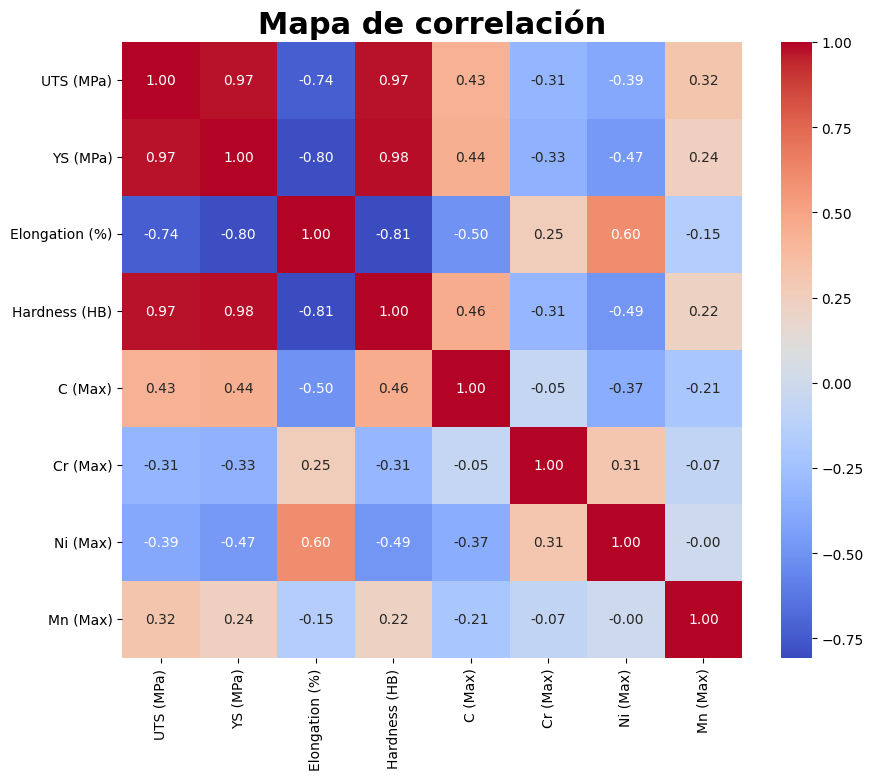

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar columnas numéricas
corr = df[[
    "UTS (MPa)",
    "YS (MPa)",
    "Elongation (%)",
    "Hardness (HB)",
    "C (Max)",
    "Cr (Max)",
    "Ni (Max)",
    "Mn (Max)"
]].corr()

# Figura
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Mapa de correlación",
    fontsize=22,
    fontweight="bold"
)

plt.show()

# Análisis ANOVA (sencillo)

In [15]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

modelo = ols(
    'Q("UTS (MPa)") ~ Q("Cr (Max)") + Q("Ni (Max)") + C(Condition_simple)',
    data=df
).fit()

anova_tabla = sm.stats.anova_lm(
    modelo,
    typ=2
)

print(anova_tabla)

                           sum_sq    df          F        PR(>F)
C(Condition_simple)  1.967543e+06   3.0  22.819528  2.826254e-08
Q("Cr (Max)")        2.132478e+04   1.0   0.741973  3.950638e-01
Q("Ni (Max)")        7.152892e+04   1.0   2.488774  1.239211e-01
Residual             9.771813e+05  34.0        NaN           NaN
